In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "Jonginn"
print("Welcome", user)


station = MultimodeStation(
    user=user,
    experiment_name = "250223_storage_swap_adding",
    hardware_config = 'CFG-HW-20260223-00005',
    multiphoton_config = 'CFG-MP-20260121-00001',
    storage_man_file = 'CFG-M1-20260218-00124',
    floquet_file = 'CFG-FL-20260223-00012',
)

USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)
# multiphoton_cfg_thisrun = AttrDict(deepcopy(mm_base_calib.multiphoton_cfg))

Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._boo

Server status: healthy
Pending jobs: 0
Welcome Jonginn
[STATION] Using hardware_config version: CFG-HW-20260223-00005
[STATION] Using multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260218-00124
[STATION] Using floquet_storage_swap version: CFG-FL-20260223-00012
Directory created at: D:\experiments\250223_storage_swap_adding\plots\autocalibration_2026-04-02
Data, plots, logs will be stored in: D:\experiments\250223_storage_swap_adding
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260223-00005.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC t

# Cavity Ramsey Refitting

In [3]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from lmfit import Model

try:
    from slab import AttrDict
except Exception:
    class AttrDict(dict):
        def __getattr__(self, k):
            try: return self[k]
            except KeyError as e: raise AttributeError(k) from e
        def __setattr__(self, k, v): self[k] = v


def _cfg_get(cfg, path, default=None):
    cur = cfg
    for key in path.split("."):
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(key, None)
        else:
            cur = getattr(cur, key, None)
    return default if cur is None else cur


def _normalize_from_obj_or_cfg(obj, avgi_2d):
    if hasattr(obj, "normalize") and callable(getattr(obj, "normalize")):
        try:
            return obj.normalize(avgi_2d)
        except Exception:
            pass

    Ig = _cfg_get(obj.cfg, "device.readout.Ig", None)
    Ie = _cfg_get(obj.cfg, "device.readout.Ie", None)
    if Ig is None or Ie is None:
        return np.array(avgi_2d, float)

    Ig = float(Ig[0] if isinstance(Ig, (list, tuple, np.ndarray)) else Ig)
    Ie = float(Ie[0] if isinstance(Ie, (list, tuple, np.ndarray)) else Ie)
    denom = (Ie - Ig)
    if denom == 0:
        return np.array(avgi_2d, float)
    return (np.array(avgi_2d, float) - Ig) / denom


def kerr_ramsey_model_phi(x, alpha2, f, phi0, scale, offset):
    return scale * np.exp(-2.0 * alpha2 * (1.0 + np.cos(2.0*np.pi*f*x + phi0))) + offset


def linear_model(x, kc, delta):
    return kc * x + delta


def post_refit_one_cavity_ramsey_v2(
    obj,
    *,
    smooth_sigma=1.5,
    rsq_threshold=0.2,
    f_window_mhz=5.0,       
    # alpha2_mode="bounded",     
    alpha2_bound_ratio=(0.3, 3.0),
    use_smoothed_for_fit=True,
    verbose=False,
    method_setting = None
):
    # x/y
    x = np.array(obj.data.get("xpts", _cfg_get(obj.cfg, "expt.kerr_lengths")), float)
    y = np.array(obj.data.get("gain_list", _cfg_get(obj.cfg, "expt.displace_gains")), float)

    avgi_2d = np.array(obj.data["g_avgi"], float)
    n_lines, n_x = avgi_2d.shape

    z = _normalize_from_obj_or_cfg(obj, avgi_2d)

    virtual_freq = float(_cfg_get(obj.cfg, "expt.ramsey_freq", 0.0) or 0.0)

    g2a = _cfg_get(obj.cfg, "device.manipulate.gain_to_alpha", None)
    man_mode_no = obj.cfg.expt.get('man_mode_no', 1)
    if isinstance(g2a, (list, tuple, np.ndarray)):
        g2a = g2a[man_mode_no-1] if len(g2a) else None

    model = Model(kerr_ramsey_model_phi)

    fit_lids, fit_results, z_fits, rsqs = [], [], [], []
    alpha2_fits, f_fits, phi0_fits = [], [], []

    for lid in range(n_lines):
        line = np.array(z[lid, :], float)
        line_sm = gaussian_filter1d(line, sigma=smooth_sigma)

        yfit = line_sm if use_smoothed_for_fit else line

        off0 = float(np.nanmin(yfit))
        sc0 = float(np.nanmax(yfit) - off0)
        sc0 = max(sc0, 1e-3)

        if g2a is not None:
            alpha_guess = float(y[lid]) * float(g2a)
            alpha2_0 = max(alpha_guess*alpha_guess, 0.0)
        else:
            alpha2_0 = 0.2  # fallback

        params = model.make_params(
            alpha2=alpha2_0,
            f=virtual_freq,
            phi0=0.0,
            scale=sc0,
            offset=off0,
        )

        # if alpha2_mode == "fixed":
        params["alpha2"].set(value=alpha2_0, vary=False)
        # elif alpha2_mode == "bounded":
        #     lo, hi = alpha2_bound_ratio
        #     params["alpha2"].set(value=alpha2_0,
        #                          min=max(lo*alpha2_0, 0.0),
        #                          max=max(hi*alpha2_0, 1e-12),
        #                          vary=True)
        # elif alpha2_mode == "free":
        #     params["alpha2"].set(value=alpha2_0, min=0.0, vary=True)
        # else:
        #     raise ValueError("alpha2_mode must be fixed|bounded|free")
        if f_window_mhz == None:
            params["f"].set(value=virtual_freq)
        else:
            params["f"].set(value=virtual_freq #)
                            , min=virtual_freq - f_window_mhz
                            , max=virtual_freq + f_window_mhz)

        params["phi0"].set(value=0.0, min=-np.pi, max=np.pi)

        params["scale"].set(value=sc0, min=0.0, max=2.0)
        params["offset"].set(value=off0)#, min=-0.5, max=1.5)

        try:
            # res = model.fit(yfit, params, x=x[lid], nan_policy="omit",
            if method_setting == "basinhopping" :
                res_global = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="basinhopping")
                res = model.fit(yfit, res_global.params, x=x[lid], nan_policy="omit", 
                                method="leastsq")
            else:
                res = model.fit(yfit, params, x=x[lid], nan_policy="omit", 
                                    method="leastsq")
            fit_lids.append(lid)
            fit_results.append(res)
            z_fits.append(res.best_fit)

            alpha2_fits.append(float(res.params["alpha2"].value))
            f_fits.append(float(res.params["f"].value))
            phi0_fits.append(float(res.params["phi0"].value))
            rsq = float(getattr(res, "rsquared", np.nan))
            rsqs.append(rsq)

            if verbose:
                print(f"lid={lid:3d} rsq={rsq:.3f} f={f_fits[-1]:.4f} phi0={phi0_fits[-1]:+.3f} alpha2={alpha2_fits[-1]:.3g}")

        except Exception as e:
            if verbose:
                print(f"lid={lid:3d} failed: {e!r}")
            continue

    fit_lids = np.array(fit_lids, int)
    rsqs = np.array(rsqs, float)
    alpha2_fits = np.array(alpha2_fits, float)
    f_fits = np.array(f_fits, float)
    phi0_fits = np.array(phi0_fits, float)
    z_fits = np.array(z_fits, float) if len(z_fits) else np.zeros((0, n_x), float)

    fit_good = np.isfinite(rsqs) & (rsqs > rsq_threshold)

    alpha2_good = alpha2_fits[fit_good]
    f_det = (f_fits[fit_good] - virtual_freq)

    # linear fit
    kc = np.nan
    delta = np.nan
    linear_fit_result = None
    try:
        if len(alpha2_good) >= 2:
            lm = Model(linear_model, independent_vars=["x"])
            lp = lm.make_params(kc=1.0, delta=0.0)
            linear_fit_result = lm.fit(f_det, lp, x=alpha2_good, nan_policy="omit")
            kc = float(linear_fit_result.params["kc"].value)
            delta = float(linear_fit_result.params["delta"].value)
    except Exception:
        pass

    obj.fit_results = AttrDict(dict(
        alpha2=alpha2_good,
        f=f_det,
        kc=kc,
        delta=delta,
        linear_fit_result=linear_fit_result,

        results=fit_results,
        z_fits=z_fits,
        rsquared=rsqs,
        fit_lids=fit_lids,
        fit_good=fit_good,

        virtual_freq=virtual_freq,
        f_window_mhz=f_window_mhz,
        # alpha2_mode=alpha2_mode,
    ))

    return obj.fit_results


Failed to read module file 'D:\python\multimode_expts\experiments\qsim\t2_cavity_fluxexcursion.py' for module 'experiments.qsim.t2_cavity_fluxexcursion': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 3793: character maps to <undefined>


In [15]:
import pickle

base_dir = "D:\\experiments\\250223_storage_swap_adding\\expt_objs\\"
pkl_files = [
    # "JOB-20260224-00259_expt.pkl", #S1
    # "JOB-20260224-00261_expt.pkl"  #S7
    # "JOB-20260224-00247_expt.pkl", #S1
    # "JOB-20260224-00251_expt.pkl",  #S7
    # "JOB-20260225-00049_expt.pkl", #S7
    "JOB-20260225-00054_expt.pkl", #S7
    "JOB-20260225-00058_expt.pkl", #S1
    "JOB-20260225-00061_expt.pkl", #S7
    "JOB-20260226-00133_expt.pkl", #S7 0.5mA
    "JOB-20260226-00134_expt.pkl", #S1 0.5mA
    "JOB-20260226-00135_expt.pkl", #S1 0.5mA
    "JOB-20260226-00136_expt.pkl", #S1 0.5mA
    "JOB-20260226-00137_expt.pkl", #S1 0.5mA
    
]
cavity_kerr_list = []
for i, pkl_file in enumerate(pkl_files):
    with open(base_dir+pkl_file, "rb") as f:
        cavity_kerr_list.append( pickle.load(f))

Text(0.5, 0.98, 'kc = 0.001030159649983085 MHz for S_1')

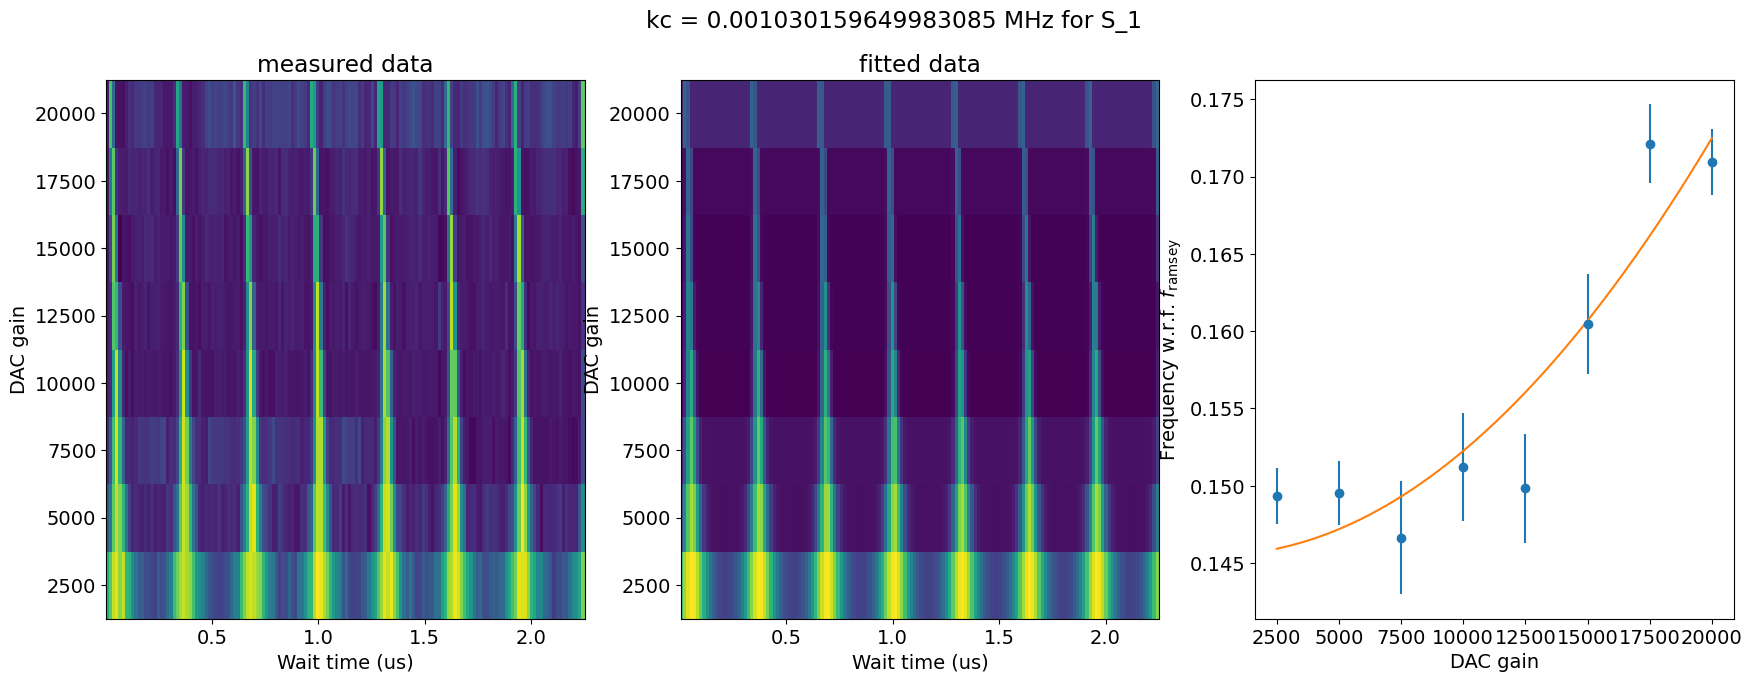

In [17]:
test = cavity_kerr_list[7]
tests=post_refit_one_cavity_ramsey_v2(test,
                                      f_window_mhz = 0.5,
                                      method_setting="basinhopping")
# test.data.keys()
data_attr = AttrDict(test.data)
fig, ax = plt.subplots(1, 3, figsize = (21,7))
X, y = data_attr.xpts, data_attr.gain_list
y_fine = np.linspace(y[0], y[-1], 1001)
Y = np.ones(np.shape(X))
# freq = np.array([tests.results[i].params["f"].value for i in range(len(y))])
freq = tests.f
freq_err = [tests.results[i].params["f"].stderr for i in range(len(y))]
kc, delta = tests.linear_fit_result.params["kc"].value, tests.linear_fit_result.params["delta"].value
alpha_2 = tests.alpha2
alpha2_fine = np.linspace(alpha_2[0], alpha_2[-1], 1001)
for i in range(len(y)):
    Y[i, :] *= y[i]
ax[0].pcolor(X, Y,
             data_attr.g_avgi)
ax[0].set_xlabel("Wait time (us)")
ax[0].set_ylabel("DAC gain")
ax[0].set_title("measured data")
ax[1].pcolor(X, Y,
             tests.z_fits)
ax[1].set_xlabel("Wait time (us)")
ax[1].set_ylabel("DAC gain")
ax[1].set_title("fitted data")
ax[2].errorbar(y[tests.fit_good], freq, 
               yerr = freq_err,
               fmt='o')
ax[2].set_xlabel("DAC gain")
ax[2].set_ylabel("Frequency w.r.f. $f_{\\mathrm{ramsey}}$")
# ax[2].errorbar(y[tests.fit_good], freq_err)
ax[2].plot(y_fine, kc * (y_fine *test.cfg.device.manipulate.gain_to_alpha[0])**2+delta)
fig.suptitle(f"kc = {kc} MHz for S_{test.cfg.expt.storage_ramsey[1]}")

# Wigner Analysis

In [9]:
print(list(range(35, 100, 1)))

[35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


In [39]:
test_wigner = pickle.load(open(pkl_files[77], "rb"))
print(test_wigner.cfg.expt.ro_stor)
print(test_wigner.cfg.expt.floquet_cycle)


5
38


In [ ]:
# Reopen old data
import pickle
import qutip as qt

pkl_files = [

# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00023_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00024_expt.pkl',
# 'D:\\experiments\\260227_qsim_purity_shots_test\\expt_objs\\JOB-20260227-00025_expt.pkl',

]

for i in range(35, 96, 1):
    base_dir = "D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\"
    base_dir += f"JOB-20260401-000{i}_expt.pkl"
    pkl_files.append(base_dir)
for i in range(6, 24, 1):
    base_dir = "D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\"
    if i < 10:
        base_dir += f"JOB-20260402-0000{i}_expt.pkl"
    else:
        base_dir += f"JOB-20260402-000{i}_expt.pkl"
    pkl_files.append(base_dir)
    
print(pkl_files)

cutoff = 15
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
# floquet_cycles = np.arange(1, 50, step=5)

outer_param = []
purity_list = []
rho_list = []
W_fits = []
x_vecs = []


data = {0: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
        1: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
        2: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
        3: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
        4: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
        5: {'floquet': [],
            'purity': [],
            'rho': [],
            'W_fits': [],
            'x_vecs': []},
}
     

for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        test_wigner = pickle.load(f)
        test_wigner.analyze_wigner(mode_state_num=cutoff, debug=True)
        test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
        print(test_wigner.cfg.expt.displacement_path)

        if len(pkl_files) == 1:
            plt.show()
        else: plt.clf()

        wigner_outputs = test_wigner.data["wigner_outputs"]

        # print(wigner_outputs["pe_plus"][0, 0, :])
        # print(wigner_outputs["pe_minus"][0, 0, :])

        rho = wigner_outputs['rho'][0][0]
        rho = np.array(rho)
        outer_param.append(test_wigner.outer_params)
        # x_vecs.append(wigner_outputs['alpha_wigner'][0][0])
        
        data_idx = test_wigner.cfg.expt.ro_stor
        data[data_idx]['floquet'].append(test_wigner.cfg.expt.floquet_cycle)
        data[data_idx]['purity'].append(np.trace(np.matmul(rho, rho)))
        data[data_idx]['rho'].append(rho)
        data[data_idx]['W_fits'].append(W_fits)
        data[data_idx]['x_vecs'].append(wigner_outputs['alpha_wigner'][0][0])
        # ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
        #                        np.arange(np.shape(rho)[0])), 
        #           np.abs(rho),
        #           cmap='viridis', vmin=0, vmax=1)
        # purity = 
        # purity_list.append(np.trace(np.matmul(rho, rho)))
        # rho_list.append(rho)
        # W_fits.append(wigner_outputs['W_fit'][0][0])

['D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00035_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00036_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00037_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00038_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00039_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00040_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00041_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00042_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00043_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20260401-00044_expt.pkl', 'D:\\experiments\\260401_quantum_walk_five_storage\\expt_objs\\JOB-20

D:\python\multimode_expts\fitting\wigner.py:373: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(10, 10))


D:\experiments\260330_storage_calib\optimized_displacements.npy
0 None
shape (257, 500)
max parity: 0.9394773551702991
max parity before scaling: 0.8079107931832527
Analyzing for floquet_cycle=0, dummy=None
D:\experiments\260330_storage_calib\optimized_displacements.npy
2 None
shape (257, 500)
max parity: 0.9541566888448348
max parity before scaling: 0.8205343993267409
Analyzing for floquet_cycle=2, dummy=None
D:\experiments\260330_storage_calib\optimized_displacements.npy
4 None
shape (257, 500)
max parity: 0.9125652434336498
max parity before scaling: 0.784767515253524
Analyzing for floquet_cycle=4, dummy=None
D:\experiments\260330_storage_calib\optimized_displacements.npy
6 None
shape (257, 500)
max parity: 0.8856531316970006
max parity before scaling: 0.7616242373237954
Analyzing for floquet_cycle=6, dummy=None
D:\experiments\260330_storage_calib\optimized_displacements.npy
8 None
shape (257, 500)
max parity: 0.8416151306733929
max parity before scaling: 0.7237534188933304
Analyzin

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

...

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


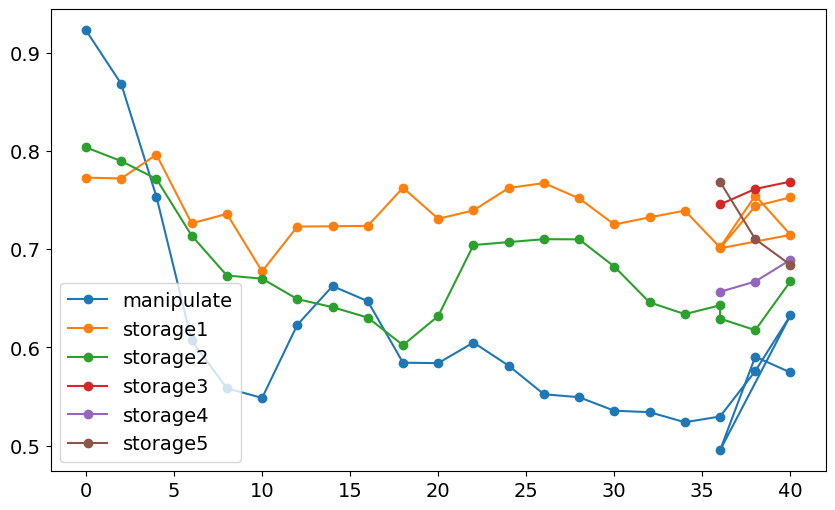

In [24]:

plt.plot(data[0]['floquet'], data[0]['purity'], label = "manipulate", marker='o')
for i in range(1, 6, 1):
    plt.plot(data[i]['floquet'], data[i]['purity'], label =f"storage{i}",marker='o')
plt.legend()

1


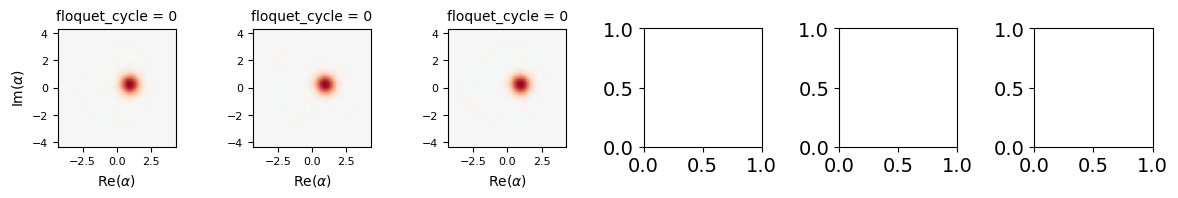

In [5]:
_n = len(pkl_files)
num_cols = 6
num_rows = _n//num_cols if (_n % num_cols == 0) else _n//num_cols + 1
print(num_rows)
fig, ax = plt.subplots(num_rows, num_cols, figsize = (num_cols * 2, num_rows * 2))
# _n -=1
for i in range(_n):
    W_fit = W_fits[i]
    r = i // num_cols
    c = i % num_cols
    vmin = -2/np.pi
    vmax = 2/np.pi
    x_vec = x_vecs[i]
    this_ax = ax[r, c] if num_rows > 1 else ax[c]
    this_ax.set_aspect('equal')
    this_ax.pcolormesh(x_vec, x_vec, W_fit, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    if c == 0:
        this_ax.set_ylabel(r'Im($\alpha$)', fontsize=10)
    if r == num_rows - 1:
        this_ax.set_xlabel(r'Re($\alpha$)', fontsize=10)
    this_ax.set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}", fontsize=10)
    this_ax.tick_params(axis='both', which='major', labelsize=8)
    
fig.tight_layout()
plt.show()